Data load :

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


Missing values check :

In [17]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

Data cleaning :

In [18]:
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')
df = df.dropna(subset=['date_added', 'rating'])
df['date_added'] = pd.to_datetime(df['date_added'].str.strip(), errors='coerce')
df['year_added'] = df['date_added'].dt.year
df.shape

(8793, 13)

Movies vs TV Shows chart :

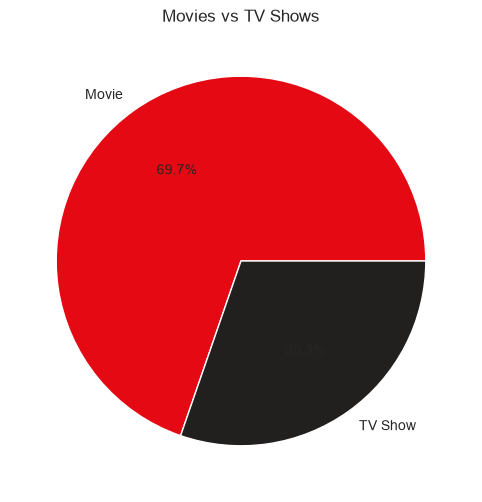

In [19]:
sns.set_style("whitegrid")
plt.figure(figsize=(6,6))
df['type'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#E50914','#221f1f'])
plt.title("Movies vs TV Shows")
plt.show()

Top 10 countries :

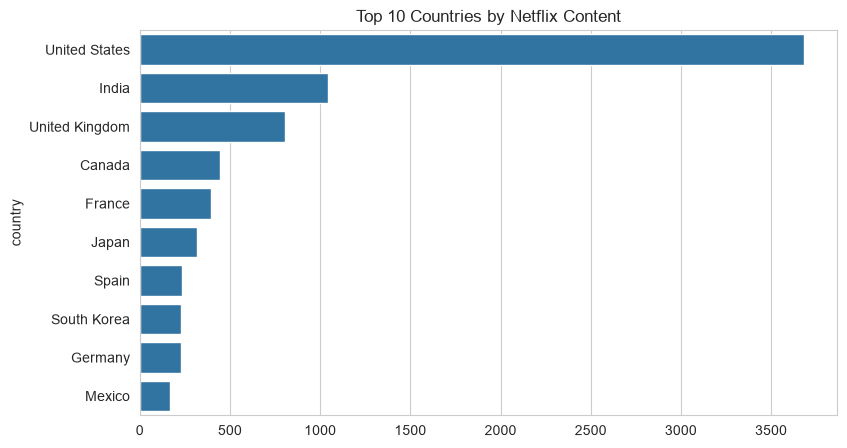

In [20]:
top_countries = df[df['country']!='Unknown']['country'].str.split(', ').explode().value_counts().head(10)
plt.figure(figsize=(9,5))
sns.barplot(x=top_countries.values, y=top_countries.index)
plt.title("Top 10 Countries by Netflix Content")
plt.show()

Yearly growth :

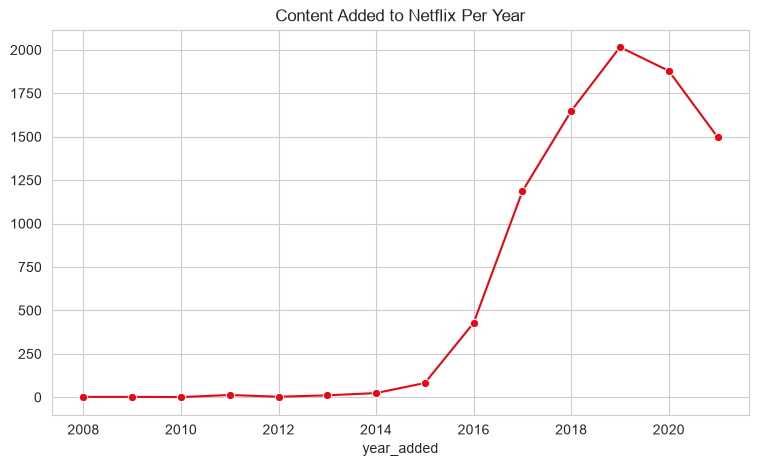

In [21]:
yearly = df['year_added'].value_counts().sort_index()
plt.figure(figsize=(9,5))
sns.lineplot(x=yearly.index, y=yearly.values, marker='o', color='#E50914')
plt.title("Content Added to Netflix Per Year")
plt.show()

Top 10 Genres :

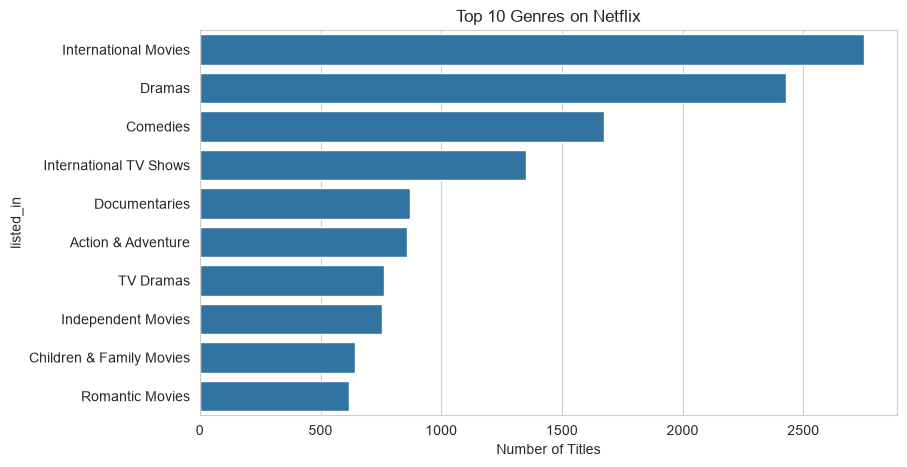

In [23]:
top_genres = df['listed_in'].str.split(', ').explode().value_counts().head(10)
plt.figure(figsize=(9,5))
sns.barplot(x=top_genres.values, y=top_genres.index)
plt.title("Top 10 Genres on Netflix")
plt.xlabel("Number of Titles")
plt.show()

Content Ratings Distribution :

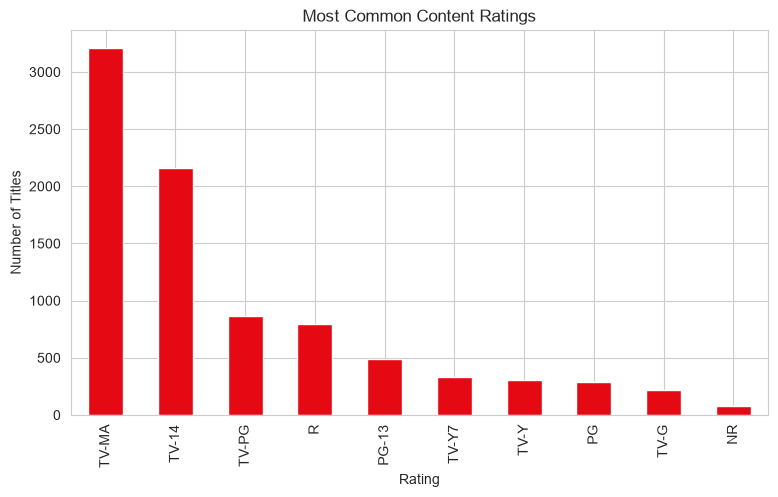

In [24]:
plt.figure(figsize=(9,5))
df['rating'].value_counts().head(10).plot(kind='bar', color='#E50914')
plt.title("Most Common Content Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Titles")
plt.show()